# Model Comparison

In [14]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from google.colab import drive

drive.mount("/content/drive")
BASE_DIR = "/content/drive/MyDrive/ML Assignment"
FINAL_MODEL_DIR = os.path.join(BASE_DIR, "final_dataset")
OUT_DIR = os.path.join(BASE_DIR, "final_comparison")
os.makedirs(OUT_DIR, exist_ok=True)

print("Base directory :", BASE_DIR)
print("Output directory:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base directory : /content/drive/MyDrive/ML Assignment
Output directory: /content/drive/MyDrive/ML Assignment/final_comparison


Load Results

In [15]:
PATHS = {
    "Logistic Regression": os.path.join(BASE_DIR, "logistic_regression", "logistic_regression_results.csv"),
    "Decision Tree": os.path.join(BASE_DIR, "decision_tree", "decision_tree_results.csv"),
    "Random Forest": os.path.join(BASE_DIR, "random_forest", "random_forest_results.csv")
}

XGB_PATH = os.path.join(BASE_DIR, "xgboost", "xgboost_lifecycle_results.csv")
MODEL_ORDER = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]
STAGES = ["Baseline Validation", "Tuned Validation", "Final Test"]
METRICS = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1",
    "ROC-AUC"
]

results = {}

# Logistic Regression / Decision Tree / Random Forest

for model, path in PATHS.items():
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{model} results file not found:\n{path}"
        )

    df = pd.read_csv( path, index_col=0).T
    df = df.loc[STAGES, METRICS].astype(float)
    results[model] = df

# XGBoost
if not os.path.exists(XGB_PATH):
    raise FileNotFoundError(
        f"XGBoost lifecycle file not found:\n{XGB_PATH}"
    )

xgb_results = pd.read_csv(XGB_PATH)
xgb_results = (
    xgb_results
    .set_index("Stage")
    .loc[STAGES, METRICS]
    .astype(float)
)

results["XGBoost"] = xgb_results
print("All saved model results loaded successfully.")

All saved model results loaded successfully.


Combined Tables

In [16]:
def stage_table(stage):

    table = pd.DataFrame({
        model: results[model].loc[stage, METRICS]
        for model in MODEL_ORDER
    }).T
    return table.astype(float)

base_table = stage_table("Baseline Validation")
val_table = stage_table("Tuned Validation")
test_table = stage_table("Final Test")

print("=== BASELINE VALIDATION ===")
display(
    base_table
    .sort_values("Macro F1", ascending=False)
    .round(4)
)

print("\n=== TUNED VALIDATION ===")
display(
    val_table
    .sort_values("Macro F1", ascending=False)
    .round(4)
)

print("\n=== FINAL TEST ===")
display(
    test_table
    .sort_values("Macro F1", ascending=False)
    .round(4)
)

=== BASELINE VALIDATION ===


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC
Logistic Regression,0.4666,0.4707,0.4566,0.4565,0.4781,0.6641
Random Forest,0.4774,0.4502,0.4548,0.4503,0.4777,0.6622
XGBoost,0.4549,0.4426,0.4412,0.4391,0.4617,0.6592
Decision Tree,0.4247,0.4707,0.4395,0.4260,0.4371,0.6519



=== TUNED VALIDATION ===


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC
Logistic Regression,0.4707,0.4739,0.4608,0.4603,0.4820,0.6643
Random Forest,0.4653,0.4632,0.4569,0.4549,0.4752,0.6634
Decision Tree,0.4676,0.4487,0.4481,0.4474,0.4724,0.6510
XGBoost,0.4637,0.4448,0.4463,0.4432,0.4681,0.6611



=== FINAL TEST ===


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC
Random Forest,0.4507,0.4506,0.4413,0.4409,0.4610,0.6493
Logistic Regression,0.4527,0.4519,0.4397,0.4407,0.4623,0.6526
XGBoost,0.4591,0.4339,0.4361,0.4338,0.4599,0.6467
Decision Tree,0.4588,0.4311,0.4313,0.4312,0.4588,0.6393


In [17]:
# COMPUTE FINAL TUNED TRAINING METRICS

y_train = pd.read_csv(os.path.join(FINAL_MODEL_DIR, "y_train.csv")
).iloc[:, 0].astype(int)

def predict_with_draw_threshold(probabilities, threshold):
    """
    Class mapping used by all final model notebooks:
        0 = Away Win
        1 = Draw
        2 = Home Win
    """

    p = np.asarray(probabilities)
    return np.where(
        p[:, 1] >= threshold, 1,
        np.where(
            p[:, 2] >= p[:, 0], 2, 0)
    )


def calculate_metrics(y_true, probabilities, threshold):

    predictions = predict_with_draw_threshold(probabilities, threshold)

    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Macro Precision": precision_score(y_true, predictions, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, predictions, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, predictions, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true,predictions, average="weighted", zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities, multi_class="ovr", average="weighted")
    }

In [18]:
# FINAL MODEL CONFIGURATION

TRAIN_CONFIG = {
    "Logistic Regression": {
        "data": os.path.join(FINAL_MODEL_DIR, "X_train_logistic.csv"),
        "model": os.path.join(BASE_DIR, "logistic_regression", "logistic_regression_tuned_pipeline.joblib"),
        "corr_columns": os.path.join(BASE_DIR, "logistic_regression", "correlation_drop_columns.joblib"),
        "threshold": os.path.join(BASE_DIR, "logistic_regression", "calibrated_draw_threshold.joblib")
    },

    "Decision Tree": {
        "data": os.path.join(FINAL_MODEL_DIR, "X_train_tree.csv"),
        "model": os.path.join(BASE_DIR, "decision_tree", "decision_tree_tuned_pipeline.joblib"),
        "corr_columns": os.path.join(BASE_DIR, "decision_tree", "correlation_dropped_columns.joblib"),
        "threshold": os.path.join(BASE_DIR, "decision_tree", "calibrated_draw_threshold.joblib")
    },

    "Random Forest": {
        "data": os.path.join(FINAL_MODEL_DIR, "X_train_tree.csv"),
        "model": os.path.join(BASE_DIR, "random_forest", "random_forest_tuned_pipeline.joblib"),
        "corr_columns": os.path.join(BASE_DIR, "random_forest", "correlation_dropped_columns.joblib"),
        "threshold": os.path.join(BASE_DIR, "random_forest", "calibrated_draw_threshold.joblib")
    },

    "XGBoost": {
        "data": os.path.join(FINAL_MODEL_DIR, "X_train_tree.csv"),
        "model": os.path.join(BASE_DIR, "xgboost", "xgboost_tuned_pipeline.joblib"),
        "corr_columns": os.path.join(BASE_DIR, "xgboost", "correlation_dropped_columns.joblib"),
        "threshold": os.path.join(BASE_DIR, "xgboost", "calibrated_draw_threshold.joblib")
    }
}

In [19]:
# GENERATE TRAINING COMPARISON TABLE
train_results = {}

for model in MODEL_ORDER:
    print(f"Processing: {model}")
    config = TRAIN_CONFIG[model]

    # Load original model-ready training data
    X_train_model = pd.read_csv(config["data"])

    market_columns = [
        column
        for column in X_train_model.columns
        if column.startswith("market_")
    ]

    X_train_model = X_train_model.drop(columns=market_columns, errors="ignore")

    # Apply the same train-only correlation filtering used during model training
    correlation_drop_columns = joblib.load(config["corr_columns"])

    X_train_model = X_train_model.drop(columns=correlation_drop_columns, errors="ignore")

    # Load final pipeline and validation-selected threshold
    pipeline = joblib.load(config["model"])
    threshold = joblib.load(config["threshold"])

    # Make sure feature order matches training
    if hasattr(
        pipeline,"feature_names_in_"):

        expected_features = list(pipeline.feature_names_in_)
        missing_features = [
            feature
            for feature in expected_features
            if feature not in X_train_model.columns
        ]

        if missing_features:
            raise ValueError(
                f"{model}: missing expected features: "
                f"{missing_features}"
            )

        X_train_model = X_train_model[expected_features]


    # Final tuned model training probabilities
    train_probabilities = pipeline.predict_proba(X_train_model)

    # Calculate the same metrics used for validation/test
    train_results[model] = calculate_metrics(
        y_train, train_probabilities, threshold)

train_table = pd.DataFrame(train_results).T
train_table = train_table.loc[MODEL_ORDER, METRICS]

print("\n=== FINAL TUNED TRAINING PERFORMANCE ===")
display(train_table.sort_values("Macro F1", ascending=False).round(4))

Processing: Logistic Regression
Processing: Decision Tree
Processing: Random Forest
Processing: XGBoost

=== FINAL TUNED TRAINING PERFORMANCE ===


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC
XGBoost,0.5080,0.4937,0.4992,0.4931,0.5124,0.6933
Random Forest,0.4747,0.4727,0.4686,0.4644,0.4848,0.6667
Decision Tree,0.4711,0.4606,0.4603,0.4567,0.4789,0.6554
Logistic Regression,0.4554,0.4660,0.4504,0.4471,0.4680,0.6570


Model Selection on Validation Macro F1

In [20]:
best_model = val_table["Macro F1"].idxmax()

print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

print(f"Selected model: {best_model}")
print(f"Training Macro F1   : {train_table.loc[best_model, 'Macro F1']:.4f}")
print(f"Validation Macro F1 : {val_table.loc[best_model, 'Macro F1']:.4f}")
print(f"Test Macro F1       : {test_table.loc[best_model, 'Macro F1']:.4f}")
print(f"Test ROC-AUC        : {test_table.loc[best_model, 'ROC-AUC']:.4f}")

FINAL MODEL SELECTION
Selected model: Logistic Regression
Training Macro F1   : 0.4471
Validation Macro F1 : 0.4603
Test Macro F1       : 0.4407
Test ROC-AUC        : 0.6526


Validation VS Test Gap (generalisation check)

In [21]:
gap = pd.DataFrame({

    "Train Macro F1":train_table["Macro F1"],
    "Validation Macro F1":val_table["Macro F1"],
    "Test Macro F1":test_table["Macro F1"],
    "Train-Val Gap":train_table["Macro F1"] - val_table["Macro F1"],
    "Val-Test Drop":val_table["Macro F1"] - test_table["Macro F1"],
    "Validation ROC-AUC":val_table["ROC-AUC"],
    "Test ROC-AUC":test_table["ROC-AUC"],
    "AUC Drop":val_table["ROC-AUC"] - test_table["ROC-AUC"]
}).round(4)

print("=== TRAIN / VALIDATION / TEST GENERALISATION ===")
display(gap)

=== TRAIN / VALIDATION / TEST GENERALISATION ===


,Train Macro F1,Validation Macro F1,Test Macro F1,Train-Val Gap,Val-Test Drop,Validation ROC-AUC,Test ROC-AUC,AUC Drop
Logistic Regression,0.4471,0.4603,0.4407,-0.0132,0.0195,0.6643,0.6526,0.0117
Decision Tree,0.4567,0.4474,0.4312,0.0093,0.0162,0.6510,0.6393,0.0117
Random Forest,0.4644,0.4549,0.4409,0.0094,0.0140,0.6634,0.6493,0.0141
XGBoost,0.4931,0.4432,0.4338,0.0499,0.0094,0.6611,0.6467,0.0144


Baseline (majority class) Reference

In [22]:
y_test = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_test.csv")
).iloc[:, 0].astype(int)

majority_class = y_train.value_counts().idxmax()

majority_predictions = np.full(
    len(y_test), majority_class)

MAJORITY_ACC = accuracy_score(
    y_test, majority_predictions)

MAJORITY_F1 = f1_score(
    y_test, majority_predictions, average="macro", zero_division=0)

print("=== MAJORITY-CLASS TEST BASELINE ===")
print(f"Accuracy : {MAJORITY_ACC:.4f}")
print(f"Macro F1 : {MAJORITY_F1:.4f}")

=== MAJORITY-CLASS TEST BASELINE ===
Accuracy : 0.4412
Macro F1 : 0.2041


Charts

In [23]:
def grouped_bar(
    metric,
    filename,
    reference=None
):

    x = np.arange(len(MODEL_ORDER))

    width = 0.25
    fig, ax = plt.subplots(figsize=(11, 6))

    train_bars = ax.bar(
        x - width,
        train_table.loc[MODEL_ORDER, metric],
        width,
        label="Train"
    )

    val_bars = ax.bar(
        x,
        val_table.loc[MODEL_ORDER, metric],
        width,
        label="Tuned Validation"
    )

    test_bars = ax.bar(
        x + width,
        test_table.loc[MODEL_ORDER, metric],
        width,
        label="Final Test"
    )

    ax.bar_label(train_bars, fmt="%.3f", fontsize=8)
    ax.bar_label(val_bars, fmt="%.3f", fontsize=8)
    ax.bar_label(test_bars, fmt="%.3f", fontsize=8)

    if reference is not None:
        ax.axhline(
            reference,
            linestyle="--",
            label=(f"Majority baseline ({reference:.3f})")
        )


    all_values = np.concatenate([
        train_table.loc[MODEL_ORDER, metric].to_numpy(),
        val_table.loc[MODEL_ORDER,metric].to_numpy(),
        test_table.loc[MODEL_ORDER,metric].to_numpy()
    ])

    lower = max(0, all_values.min() - 0.05)
    upper = min(1, all_values.max() + 0.05)
    ax.set_ylim(lower, upper)

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=10)

    ax.set_ylabel(metric)
    ax.set_title(f"{metric}: Train vs Validation vs Test")

    ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename),
        dpi=300, bbox_inches="tight")
    plt.show()

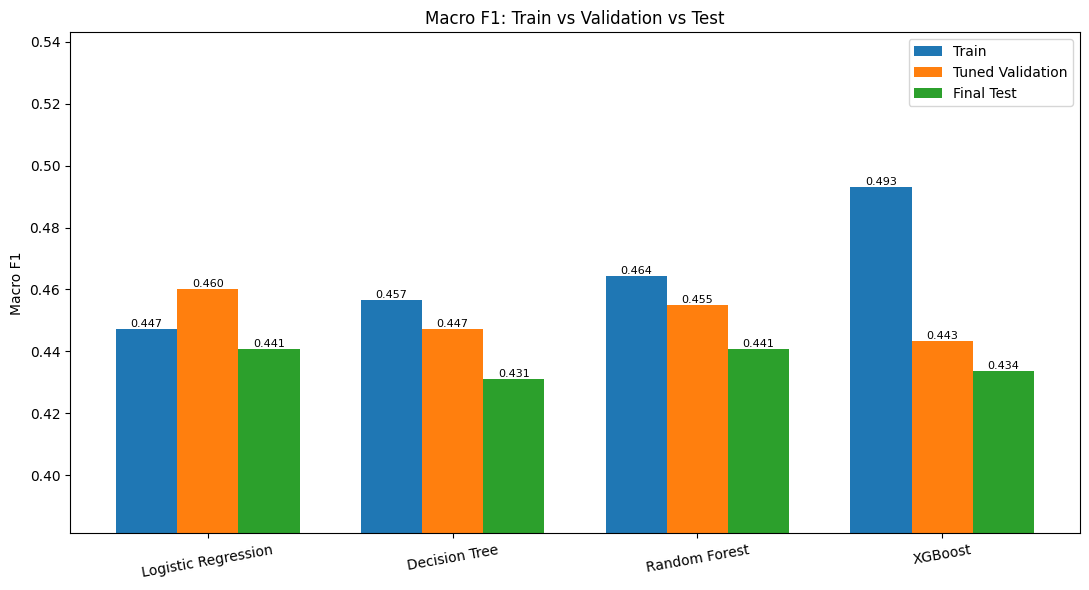

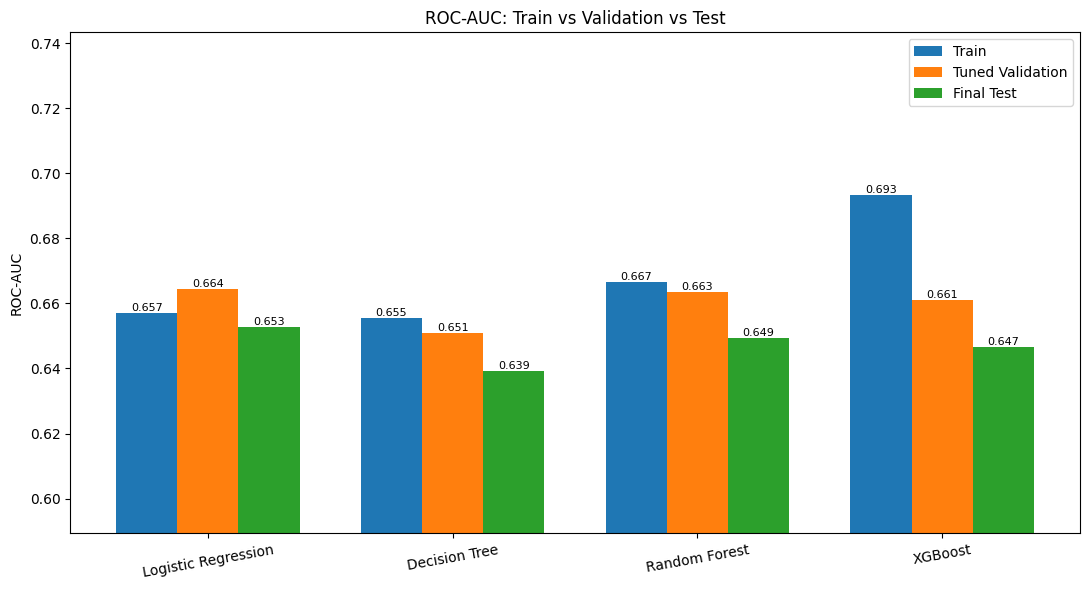

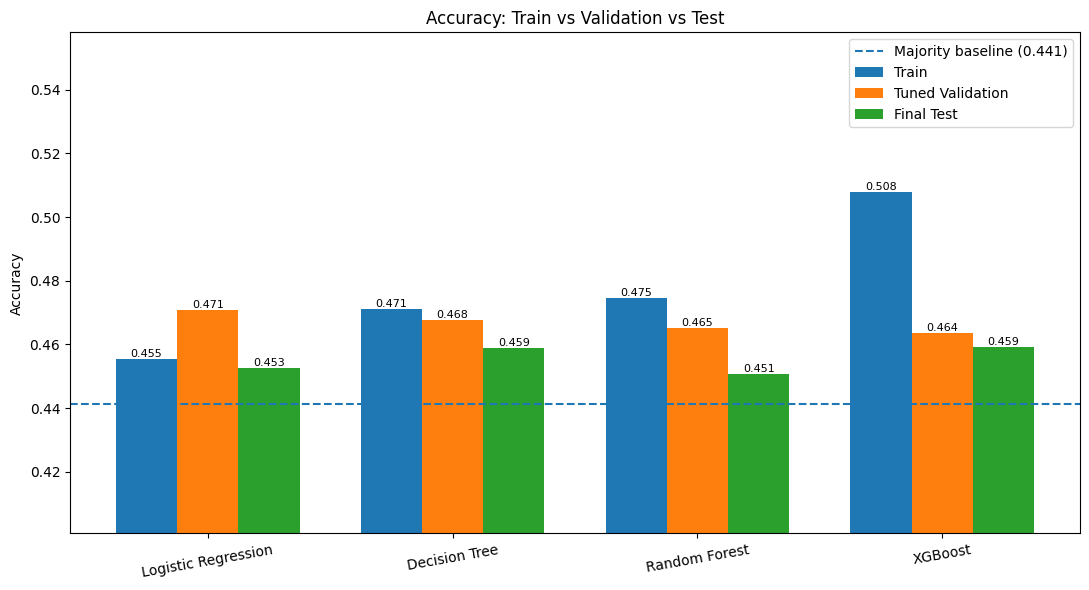

In [24]:
grouped_bar(
    "Macro F1", "comparison_macro_f1.png")

grouped_bar(
    "ROC-AUC", "comparison_roc_auc.png")

grouped_bar(
    "Accuracy", "comparison_accuracy.png",
    reference=MAJORITY_ACC)

In [25]:
summary_rows = []

for model in MODEL_ORDER:

    summary_rows.append({
        "Model": model,
        "Train Accuracy":train_table.loc[model, "Accuracy"],
        "Train Macro F1":train_table.loc[model, "Macro F1"],

        "Validation Accuracy":val_table.loc[model, "Accuracy"],
        "Validation Macro F1":val_table.loc[model, "Macro F1"],
        "Validation ROC-AUC":val_table.loc[model, "ROC-AUC"],

        "Test Accuracy":test_table.loc[model, "Accuracy"],
        "Test Macro F1":test_table.loc[model, "Macro F1"],
        "Test ROC-AUC":test_table.loc[model, "ROC-AUC"]
    })


final_summary = pd.DataFrame(summary_rows)
final_summary = final_summary.sort_values(
    "Validation Macro F1",ascending=False
).reset_index(drop=True)

print("=== FINAL MODEL COMPARISON SUMMARY ===")
display(final_summary.round(4))

=== FINAL MODEL COMPARISON SUMMARY ===


,Model,Train Accuracy,Train Macro F1,Validation Accuracy,Validation Macro F1,Validation ROC-AUC,Test Accuracy,Test Macro F1,Test ROC-AUC
0,Logistic Regression,0.4554,0.4471,0.4707,0.4603,0.6643,0.4527,0.4407,0.6526
1,Random Forest,0.4747,0.4644,0.4653,0.4549,0.6634,0.4507,0.4409,0.6493
2,Decision Tree,0.4711,0.4567,0.4676,0.4474,0.6510,0.4588,0.4312,0.6393
3,XGBoost,0.5080,0.4931,0.4637,0.4432,0.6611,0.4591,0.4338,0.6467


Save Outputs

In [26]:
# SAVE FINAL COMPARISON OUTPUTS
train_table.to_csv(os.path.join(OUT_DIR, "comparison_train.csv"))
val_table.to_csv(os.path.join(OUT_DIR, "comparison_validation.csv"))
test_table.to_csv(os.path.join(OUT_DIR, "comparison_test.csv"))
base_table.to_csv(os.path.join(OUT_DIR, "comparison_baseline_validation.csv"))
gap.to_csv(os.path.join(OUT_DIR, "comparison_generalisation_gap.csv"))
final_summary.to_csv(os.path.join(OUT_DIR, "final_model_comparison.csv"), index=False)

print("=" * 60)
print("MODEL COMPARISON OUTPUTS SAVED")
print("=" * 60)

print("Saved to:", OUT_DIR)
print("\nFiles created:")

print("- comparison_train.csv")
print("- comparison_validation.csv")
print("- comparison_test.csv")
print("- comparison_baseline_validation.csv")
print("- comparison_generalisation_gap.csv")
print("- final_model_comparison.csv")
print("- comparison_macro_f1.png")
print("- comparison_roc_auc.png")
print("- comparison_accuracy.png")

MODEL COMPARISON OUTPUTS SAVED
Saved to: /content/drive/MyDrive/ML Assignment/final_comparison

Files created:
- comparison_train.csv
- comparison_validation.csv
- comparison_test.csv
- comparison_baseline_validation.csv
- comparison_generalisation_gap.csv
- final_model_comparison.csv
- comparison_macro_f1.png
- comparison_roc_auc.png
- comparison_accuracy.png
